# 260414-3: CNN Training Techniques — Augmentation, BatchNorm, Residual

이번 실습은 `4.cnn.pdf` 후반부의 **Training Techniques**와 **Notable CNN Architectures**에 맞춰 진행합니다.  
CNN을 단순히 쌓는 것에서 나아가 augmentation, normalization, BatchNorm, Dropout, residual connection을 적용해 학습 안정성과 일반화 성능을 개선하는 방법을 다룹니다.

## 학습 목표
- data augmentation과 normalization pipeline을 구성한다.
- BatchNorm과 Dropout이 `train()` / `eval()` 모드에서 다르게 동작함을 확인한다.
- BatchNorm과 Dropout이 포함된 CNN을 구현한다.
- ResNet의 핵심인 residual block을 구현한다.

## 구성
| 순서 | 내용 | 핵심 질문 |
|---|---|---|
| 1 | Augmentation & preprocessing | 학습 데이터만 무작위로 바꾸는 이유는 무엇인가? |
| 2 | Training utilities | 평가 시 `model.eval()`이 왜 필요한가? |
| 3 | BN + Dropout CNN | BatchNorm과 Dropout은 모델 안에서 어디에 들어가는가? |
| 4 | Plain vs augmented training | augmentation은 train/validation 결과에 어떤 영향을 주는가? |
| 5 | Residual block | `F(x) + x`는 깊은 네트워크 학습에 어떤 도움을 주는가? |

## 이론 설명

### 핵심 개념 정리
CNN의 성능은 architecture뿐 아니라 학습 기법에도 크게 좌우됩니다. 강의 후반부에서 다룬 기법들은 서로 다른 문제를 해결합니다.

| 기법 | 해결하려는 문제 | PyTorch 표현 |
|---|---|---|
| Data augmentation | 데이터 부족과 overfitting | `transforms.RandomCrop`, `RandomHorizontalFlip` |
| Normalization | 입력 scale 불안정 | `transforms.Normalize` |
| BatchNorm | layer 입력 분포 변화와 학습 불안정 | `nn.BatchNorm2d` |
| Dropout | co-adaptation과 overfitting | `nn.Dropout`, `nn.Dropout2d` |
| Residual connection | 깊은 모델의 gradient 흐름 문제 | `self.block(x) + x` |

이번 실습은 성능 숫자만 보는 실험이 아니라, 각 기법이 코드상 어디에 들어가며 어떤 관찰을 만들어내는지 이해하는 것이 목적입니다.

### 실습 체크리스트

이번 노트북은 여러 학습 기법이 한 번에 나오므로, 아래 질문에 답하면서 진행하면 흐름을 놓치지 않습니다.

- augmentation은 학습 데이터에만 적용되고 있는가?
- validation/test transform에는 random 연산이 없는가?
- BatchNorm과 Dropout이 있는 모델을 평가할 때 `model.eval()`을 호출하는가?
- residual block에서 더해지는 두 tensor의 shape이 같은가?

이 질문들은 수업용 예제뿐 아니라 실제 프로젝트에서도 그대로 쓰이는 점검표입니다.

## 코드 실습

이제 학습 기법을 실제 PyTorch 코드에 넣어봅니다. 학습용 transform과 평가용 transform을 분리하고, BatchNorm/Dropout이 들어간 모델과 residual block을 차례로 구현합니다.

이번 노트북의 결과는 실행 환경과 subset에 따라 흔들릴 수 있습니다. 숫자 하나보다 transform 구성, train/eval mode, shape 흐름이 올바른지 확인하는 것이 더 중요합니다.

### 실행 안내

이번 노트북도 CIFAR-10을 사용합니다. 다만 260414-2와 달리 학습용 transform과 평가용 transform을 분리합니다.

- 학습용 transform: augmentation을 포함합니다.
- 평가용 transform: deterministic해야 하므로 augmentation을 넣지 않습니다.
- train/validation/test split은 같은 class 구성을 유지하되 수업 시간에 맞게 subset으로 제한합니다.

In [1]:
# Colab / local environment check
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if gpu_info.returncode == 0:
        print('GPU available')
        print(gpu_info.stdout.split('\n')[0])
    else:
        print('GPU is not available. Runtime > Change runtime type > GPU 를 선택하세요.')
else:
    print('Running outside Colab')


GPU available
Tue Apr 14 06:33:17 2026       


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## 1. Augmentation and Preprocessing

강의의 data augmentation은 실제 label은 유지하면서 입력 이미지를 다양하게 만들어 regularization 효과를 냅니다.  
CIFAR-10에서는 random crop과 horizontal flip이 가장 기본적인 조합입니다.

### 데이터 안내

강의의 data augmentation은 실제로 존재하지 않는 새로운 데이터를 만드는 가장 간단한 방법입니다. label은 유지하되 입력 이미지를 조금씩 바꿔 모델이 특정 위치나 방향에 과하게 의존하지 않도록 합니다.

CIFAR-10에서 자주 쓰는 기본 조합은 다음과 같습니다.

- `RandomCrop(32, padding=4)`: 가장자리에 여백을 붙인 뒤 32x32 영역을 무작위로 잘라 translation 변화에 강하게 만듭니다.
- `RandomHorizontalFlip()`: 좌우 반전이 label을 바꾸지 않는 class에서 효과적입니다.
- `Normalize(mean, std)`: channel별 scale을 맞춰 optimization을 안정화합니다.

주의할 점은 validation/test에는 random augmentation을 넣지 않는 것입니다. 평가 데이터가 매번 바뀌면 성능 비교가 불안정해집니다.

In [3]:
FAST_DEV_RUN = True
BATCH_SIZE = 128
NUM_WORKERS = 2
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)


### ※ Batch size는 어떻게 정하나요?
사용 가능한 computing 자원에 맞춰 최대한 크게  
단, Batch size가 커질 수록 learning rate도 키워주는 것이 중요


### 구현 안내

아래 TODO는 학습용 transform을 완성하는 부분입니다. transform은 위에서 아래 순서대로 적용됩니다.

추천 순서는 `RandomCrop -> RandomHorizontalFlip -> ToTensor -> Normalize`입니다. 이미지 공간에서 해야 하는 augmentation은 tensor 변환 전에 두고, tensor가 된 뒤에는 normalization을 적용합니다.

만약 augmentation을 너무 강하게 넣으면 작은 모델이나 짧은 epoch에서는 오히려 학습이 어려워질 수 있습니다. 여기서는 강의 개념 확인을 위해 가장 표준적인 두 가지만 사용합니다.

※ 추가적인 augmentation에 대해서는 아래 링크를 참고하세요.  
https://docs.pytorch.org/vision/0.21/transforms.html#v2-api-reference-recommended

In [4]:
train_transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])


In [5]:
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

data_root = './data'
train_aug_full = torchvision.datasets.CIFAR10(root=data_root, train=True, download=True, transform=train_transform_aug)
train_plain_full = torchvision.datasets.CIFAR10(root=data_root, train=True, download=True, transform=eval_transform)
test_full = torchvision.datasets.CIFAR10(root=data_root, train=False, download=True, transform=eval_transform)
classes = train_aug_full.classes

train_size = 5000 if FAST_DEV_RUN else 45000
val_size = 1000 if FAST_DEV_RUN else 5000
test_size = 1000 if FAST_DEV_RUN else len(test_full)

train_aug = Subset(train_aug_full, list(range(train_size)))
train_plain = Subset(train_plain_full, list(range(train_size)))
val_set = Subset(train_plain_full, list(range(train_size, train_size + val_size)))
test_set = Subset(test_full, list(range(test_size)))

train_aug_loader = DataLoader(train_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
train_plain_loader = DataLoader(train_plain, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'train/val/test: {len(train_aug)}, {len(val_set)}, {len(test_set)}')


100%|██████████| 170M/170M [00:04<00:00, 39.1MB/s]


train/val/test: 5000, 1000, 1000


### 관찰 포인트

같은 index의 이미지를 여러 번 꺼내도 augmentation 때문에 매번 조금씩 다른 이미지가 나옵니다. 이 셀은 augmentation이 실제로 적용되고 있는지 눈으로 확인하기 위한 셀입니다.

crop 위치나 좌우 반전이 달라져도 class label은 그대로 유지됩니다. 모델 입장에서는 같은 object를 다양한 위치와 형태로 보는 효과가 납니다.

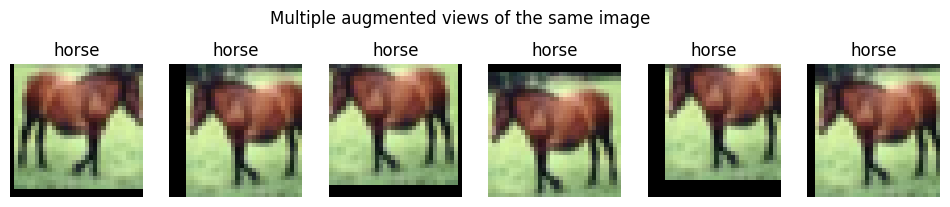

In [6]:
def denormalize(img):
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(3, 1, 1)
    return torch.clamp(img.cpu() * std + mean, 0, 1)

# 같은 index를 여러 번 augmentation해서 보기
base_idx = 7
fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
for ax in axes:
    img, label = train_aug_full[base_idx]
    ax.imshow(denormalize(img).permute(1, 2, 0))
    ax.set_title(classes[label])
    ax.axis('off')
plt.suptitle('Multiple augmented views of the same image')
plt.show()


## 2. Training Utilities

### 코드 읽기

학습 함수는 260414-2와 거의 같지만 optimizer를 `AdamW`로 바꿨습니다. `AdamW`는 weight decay를 Adam 업데이트와 분리해서 적용하는 optimizer로, vision 모델에서도 자주 사용됩니다.

`check_accuracy`에서는 반드시 `model.eval()`을 호출합니다. 이번 노트북에는 BatchNorm과 Dropout이 들어가므로 평가 모드를 빼먹으면 validation accuracy가 불안정해질 수 있습니다.

In [7]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def check_accuracy(loader, model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            scores = model(x)
            pred = scores.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()
    return 100.0 * correct / total

def train_model(model, train_loader, val_loader, epochs=2, lr=1e-3, weight_decay=1e-4):
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            scores = model(x)
            loss = criterion(scores, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * y.size(0)
            correct += (scores.argmax(dim=1) == y).sum().item()
            total += y.numel()

        history['train_loss'].append(total_loss / total)
        history['train_acc'].append(100.0 * correct / total)
        history['val_acc'].append(check_accuracy(val_loader, model))
        if epoch % 10 == 0:
          print(f"Epoch {epoch:02d}: loss={history['train_loss'][-1]:.4f}, train_acc={history['train_acc'][-1]:.2f}%, val_acc={history['val_acc'][-1]:.2f}%")
    return history

def plot_histories(histories):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for name, hist in histories.items():
        axes[0].plot(hist['train_loss'], marker='o', label=name)
        axes[1].plot(hist['val_acc'], marker='o', label=name)
    axes[0].set_title('train loss')
    axes[0].set_xlabel('epoch')
    axes[1].set_title('validation accuracy')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('accuracy (%)')
    axes[0].legend()
    axes[1].legend()
    plt.show()


## 3. BatchNorm and Dropout Model

BatchNorm은 각 layer 입력 분포를 안정화하고, Dropout은 co-adaptation을 줄이는 regularization으로 자주 쓰입니다.

### 모델 설계 안내

`CNNWithBNDropout`은 VGG 스타일의 작은 3x3 convolution을 반복하는 구조입니다. 각 block은 다음 의도를 가집니다.

- `Conv2d`: local feature를 추출합니다.
- `BatchNorm2d`: channel별 activation 분포를 안정화합니다.
- `ReLU`: 비선형성을 추가합니다.
- `MaxPool2d`: spatial 크기를 줄여 receptive field를 키웁니다.
- `Dropout`: 일부 activation을 무작위로 꺼서 overfitting을 줄입니다.

`bias=False`는 BatchNorm이 뒤따를 때 자주 쓰는 설정입니다. BatchNorm에 learnable shift가 있으므로 convolution bias가 중복될 수 있기 때문입니다.

In [9]:
class CNNWithBNDropout(nn.Module):
    """Conv block에 BatchNorm과 Dropout을 추가한 CNN."""
    def __init__(self, num_classes=10, dropout_p=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(dropout_p),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(dropout_p),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


### ※ Batch Normalization은 왜 정규화 후 learnable parameter로 다시 scaling, biasing을 할까요?
1. 보통 `ReLU`를 직후 통과시키기 때문
2. 모델이 정규화를 학습에 따라 취소할 수 있도록 자유 부여
3. 유연한 스케일링으로 표현력 강화

### 검증 안내

모델 구현 후 dummy input을 넣어 출력 shape을 확인합니다. 입력이 `(4, 3, 32, 32)`이면 class score 출력은 `(4, 10)`이어야 합니다.

이 셀에서 오류가 나면 대부분 `Linear` 입력 차원이 틀린 경우입니다. 두 번의 `MaxPool2d(2)`를 지나면 32x32가 16x16, 다시 8x8이 되므로 flatten 차원은 `64 * 8 * 8`입니다.

In [10]:
model_bn = CNNWithBNDropout(dropout_p=0.25).to(device)
dummy = torch.randn(4, 3, 32, 32).to(device)
out = model_bn(dummy)
print('output shape:', tuple(out.shape))
print('params:', f'{count_params(model_bn):,}')
assert tuple(out.shape) == (4, 10)


output shape: (4, 10)
params: 1,117,162


### train() vs eval() mode

BatchNorm과 Dropout은 `model.train()` / `model.eval()` 모드에 따라 동작이 달라집니다.

### 모드 전환 안내

BatchNorm과 Dropout은 학습 모드와 평가 모드에서 다르게 동작합니다.

- Dropout은 train mode에서만 activation 일부를 무작위로 0으로 만듭니다. eval mode에서는 꺼집니다.
- BatchNorm은 train mode에서 mini-batch 통계를 사용하고 running mean/variance를 업데이트합니다. eval mode에서는 저장된 running 통계를 사용합니다.

따라서 학습 loop에서는 `model.train()`, validation/test에서는 `model.eval()`이 습관처럼 들어가야 합니다.

In [11]:
demo = nn.Sequential(
    nn.Conv2d(3, 8, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(8),
    nn.ReLU(),
    nn.Dropout2d(p=0.5),
).to(device)

x = torch.randn(2, 3, 8, 8).to(device)

demo.train()
out_train_1 = demo(x)
out_train_2 = demo(x)

demo.eval()
out_eval_1 = demo(x)
out_eval_2 = demo(x)

print('train outputs equal?', torch.allclose(out_train_1, out_train_2))
print('eval outputs equal? ', torch.allclose(out_eval_1, out_eval_2))
print('Dropout makes train-mode stochastic, eval-mode deterministic.')


train outputs equal? False
eval outputs equal?  True
Dropout makes train-mode stochastic, eval-mode deterministic.


## 4. Plain vs Augmented Training

### 비교 실험 안내

plain transform과 augmented transform으로 같은 구조의 모델을 학습해 비교합니다. 짧은 subset 학습에서는 augmentation 모델이 즉시 더 높은 validation accuracy를 보장하지 않을 수 있습니다.

해석할 때는 다음을 구분하세요.

- augmentation은 train accuracy를 낮출 수 있습니다. 매번 더 어려운 입력을 보기 때문입니다.
- 대신 충분히 학습하면 validation/test generalization이 좋아지는 경우가 많습니다.
- 아주 짧은 실습에서는 성능 숫자보다 학습 pipeline을 올바르게 구성하는 것이 핵심입니다.

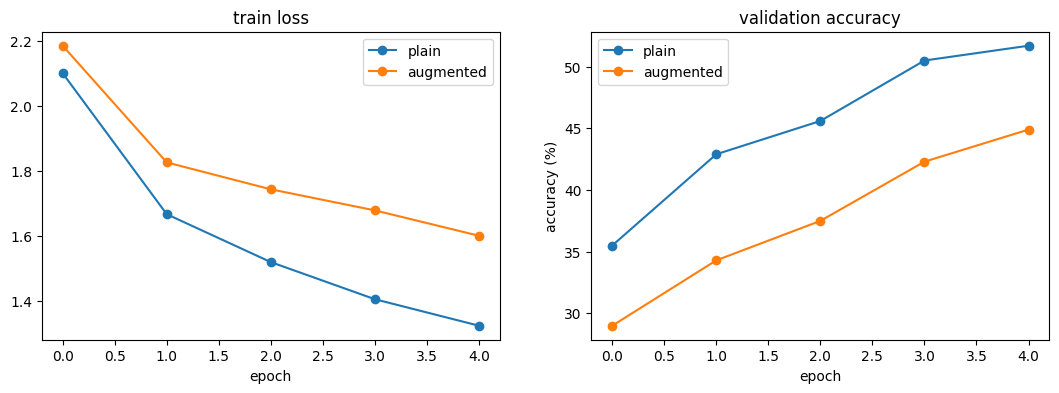

Augmented model test accuracy: 43.90%


In [ ]:
torch.manual_seed(seed)
plain_model = CNNWithBNDropout(dropout_p=0.25).to(device)
plain_hist = train_model(plain_model, train_plain_loader, val_loader, epochs=5, lr=1e-3)

torch.manual_seed(seed)
aug_model = CNNWithBNDropout(dropout_p=0.25).to(device)
aug_hist = train_model(aug_model, train_aug_loader, val_loader, epochs=5, lr=1e-3)

plot_histories({'plain': plain_hist, 'augmented': aug_hist})
print('Augmented model test accuracy:', f'{check_accuracy(test_loader, aug_model):.2f}%')


## 5. Residual Connection

ResNet의 핵심은 block이 직접 $H(x)$를 학습하는 대신 residual $F(x)=H(x)-x$를 학습하고, 출력에서 $F(x)+x$를 만드는 것입니다.  
이 identity path는 깊은 네트워크의 gradient 흐름을 돕습니다.

### 구현 안내

Residual block은 입력 `x`를 block 출력에 더합니다. 이때 더하려면 shape이 같아야 합니다. 이번 block은 입력과 출력 channel 수를 같게 유지하고 padding 1의 3x3 convolution을 사용하므로 spatial 크기도 유지됩니다.

구현 순서는 다음과 같습니다.

1. `self.block`에서 `Conv-BN-ReLU-Conv-BN`을 만듭니다.
2. `forward`에서 `self.block(x)`를 계산합니다.
3. 원래 입력 `x`를 더합니다.
4. 마지막에 ReLU를 적용합니다.

이 짧은 identity path가 깊은 network의 gradient 흐름을 도와 ResNet의 핵심 아이디어가 됩니다.

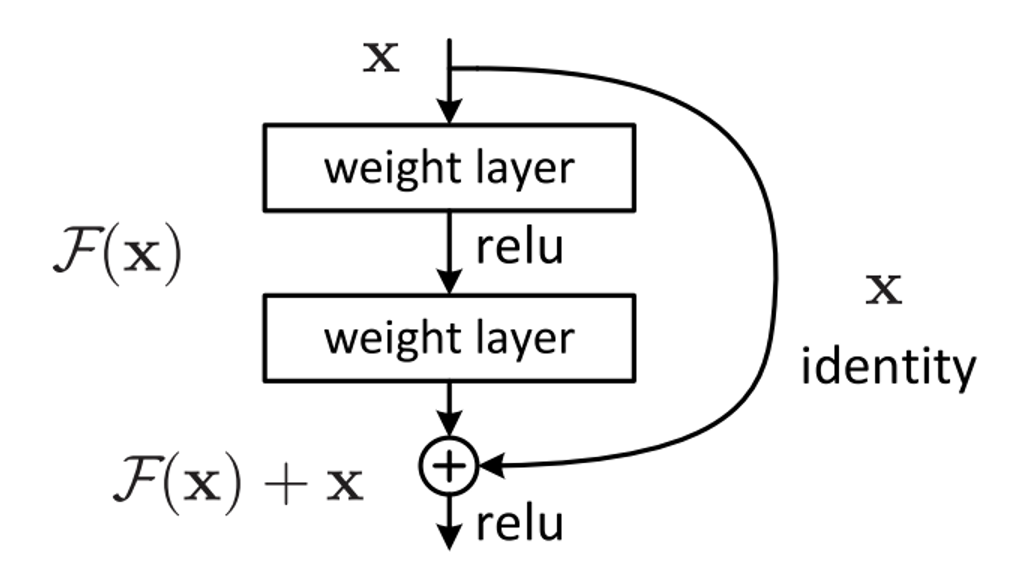

In [12]:
class ResidualBlock(nn.Module):
    """ResNet의 핵심 아이디어: F(x) + x."""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.block(x) + x)
        return x


In [16]:
class TinyResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.stage1 = nn.Sequential(
            ResidualBlock(32),
            ResidualBlock(32),
            nn.MaxPool2d(2),
        )
        self.stage2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResidualBlock(64),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.head(x)
        return x

res_model = TinyResNet().to(device)
out = res_model(torch.randn(4, 3, 32, 32).to(device))
print('output shape:', tuple(out.shape))
print('params:', f'{count_params(res_model):,}')
assert tuple(out.shape) == (4, 10)


output shape: (4, 10)
params: 131,242


### 학습 안내

`TinyResNet`은 ResNet의 전체 구조를 그대로 재현한 것은 아니지만, residual connection의 핵심을 CIFAR-10 크기에 맞게 줄인 모델입니다.

`AdaptiveAvgPool2d((1, 1))`는 spatial 크기와 관계없이 channel별 평균을 내서 `(N, C, 1, 1)`로 만듭니다. 그래서 마지막 classifier는 `Linear(64, 10)`처럼 간단해집니다. 최근 CNN에서는 큰 fully-connected head보다 이런 global average pooling을 자주 사용합니다.

In [17]:
torch.manual_seed(seed)
res_model = TinyResNet().to(device)
res_hist = train_model(res_model, train_aug_loader, val_loader, epochs=5 if FAST_DEV_RUN else 5, lr=1e-3)

plot_histories({'BN+Dropout CNN': aug_hist, 'TinyResNet': res_hist})
print('TinyResNet test accuracy:', f'{check_accuracy(test_loader, res_model):.2f}%')


NameError: name 'aug_hist' is not defined

## Summary

이번 실습에서는 CNN 성능과 안정성을 높이는 기본 도구를 살펴보았습니다.

| 기법 | 역할 |
|---|---|
| Data augmentation | fake data를 만들어 overfitting 완화 |
| Normalization | 입력 scale을 안정화 |
| BatchNorm | layer 입력 분포를 안정화하고 학습을 빠르게 만듦 |
| Dropout | train-time stochastic regularization |
| Residual connection | 깊은 네트워크에서 gradient 경로를 짧게 제공 |